In [1]:
def get_exp_results(input_data):
    exp_results = {}
    for task in input_data:
        result = {}

        task_id = task["task_id"]
        num_turns = 0
        for turn in task["traj"]:
            if turn["role"] == "assistant" and "tool_calls" not in turn:
                num_turns += 1
        user_typing_time = task["user_typing_time"] if "user_typing_time" in task else task["response_time"]
        baseline_api_count = task["num_tool_calls"]
        # apis in the background
        background_api_calls = []
        for guesser_turn_log in task["guesser_logs"]:
            background_api_calls_turn = []
            # there's only one decider
            for item in guesser_turn_log["deciders"][0]["trajectory"]:
                if item["role"] == "tool":
                    api_call = {}
                    api_call["name"] = item["output"]["tool_calls"][0]["function"]["name"]
                    api_call["arguments"] = item["output"]["tool_calls"][0]["function"]["arguments"]
                    api_call["execution_time"] = item["execution_time"]
                    background_api_calls_turn.append(api_call)
            background_api_calls.append(background_api_calls_turn)
        # baseline api calls
        baseline_api_calls = []
        baseline_api_calls_turn = []
        first_turn = True
        for item in task["traj"]:
            if item["role"] == "user":
                if not first_turn:
                    baseline_api_calls.append(baseline_api_calls_turn)
                baseline_api_calls_turn = []
                first_turn = False
            if item["role"] == "assistant" and "tool_calls" in item:
                api_call = {}
                api_call["name"] = item["tool_calls"][0]["function"]["name"]
                api_call["arguments"] = item["tool_calls"][0]["function"]["arguments"]
                baseline_api_calls_turn.append(api_call)

        # cost in the background
        guesser_time_cost = 0
        guesser_complete_token_cost = 0
        guesser_price_cost = 0
        guesser_thinking_tokens = 0
        guesser_output_tokens = 0

        decider_time_cost = 0
        decider_complete_token_cost = 0
        decider_price_cost = 0
        decider_thinking_tokens = 0
        decider_output_tokens = 0

        for guesser_turn_log in task["guesser_logs"]:
            # there's only one guesser
            guesser_time_cost += guesser_turn_log["guessers"][0]["time"]
            # guesser_complete_token_cost += guesser_turn_log["guessers"][0]["input_token_length"] + guesser_turn_log["guessers"][0]["output_token_length"] + guesser_turn_log["guessers"][0]["reasoning_token_length"]
            guesser_complete_token_cost += guesser_turn_log["guessers"][0]["output_token_length"] + guesser_turn_log["guessers"][0]["reasoning_token_length"]
            guesser_thinking_tokens += guesser_turn_log["guessers"][0]["reasoning_token_length"]
            guesser_output_tokens += guesser_turn_log["guessers"][0]["output_token_length"]
            guesser_price_cost += guesser_turn_log["guessers"][0]["price_cost"]

            for item in guesser_turn_log["deciders"][0]["trajectory"]:
                # decider_time_cost += item["execution_time"]
                # decider_complete_token_cost += item["input_token_length"] + item["output_token_length"] + item["reasoning_token_length"]
                decider_complete_token_cost += item["output_token_length"] + item["reasoning_token_length"]
                decider_output_tokens += item["output_token_length"]
                # decider_complete_token_cost += item["reasoning_token_length"]
                decider_thinking_tokens += item["reasoning_token_length"]
                decider_price_cost += item["price_cost"]
                decider_time_cost += item["time"]
                break

        result["task_id"] = task_id
        result["num_turns"] = num_turns
        result["total_api_count"] = sum(baseline_api_count)
        result["baseline_api_calls"] = baseline_api_calls
        result["background_api_calls"] = background_api_calls
        result["user_typing_time"] = user_typing_time
        
        result["guesser_time_cost"] = guesser_time_cost
        result["guesser_complete_token_cost"] = guesser_complete_token_cost
        result["guesser_thinking_tokens"] = guesser_thinking_tokens
        result["guesser_output_tokens"] = guesser_output_tokens
        result["guesser_price_cost"] = guesser_price_cost
        result["decider_time_cost"] = decider_time_cost
        result["decider_complete_token_cost"] = decider_complete_token_cost
        result["decider_thinking_tokens"] = decider_thinking_tokens
        result["decider_output_tokens"] = decider_output_tokens
        result["decider_price_cost"] = decider_price_cost
        exp_results[task_id] = result
    return exp_results

In [2]:
import json
gpt5_low_filepath = "./results/gpt-5-nano_low_no_check_0-115_0917210712.json"
gpt5_medium_filepath = "./results/gpt-5-mini_medium_no_check_0-115_0917210712.json"
gpt5_high_filepath = "./results/gpt-5_high_no_check_0-115_0917210712.json"

gpt5_low_data = json.load(open(gpt5_low_filepath))
gpt5_medium_data = json.load(open(gpt5_medium_filepath))
gpt5_high_data = json.load(open(gpt5_high_filepath))

gpt5_low_results = get_exp_results(gpt5_low_data)
gpt5_medium_results = get_exp_results(gpt5_medium_data)
gpt5_high_results = get_exp_results(gpt5_high_data)

gemini_low_filepath = "./results/gemini-2.5-flash_low_no_check_0-115_0920194916.json"
gemini_medium_filepath = "./results/gemini-2.5-flash_medium_no_check_0-115_0920231151.json"
gemini_high_filepath = "./results/gemini-2.5-flash_high_no_check_0-115_0921001824.json"


gemini_low_data = json.load(open(gemini_low_filepath))
gemini_medium_data = json.load(open(gemini_medium_filepath))
gemini_high_data = json.load(open(gemini_high_filepath))

gemini_low_results = get_exp_results(gemini_low_data)
gemini_medium_results = get_exp_results(gemini_medium_data)
gemini_high_results = get_exp_results(gemini_high_data)




In [3]:
def get_cost_per_conversation(analysis_data):
    exp = {
        "price_cost": [],
        "time_cost": [],
        "thinking_tokens": [],
        "complete_tokens": [],
        "output_tokens": [],
        "time_cost_per_turn": [],
        "price_cost_per_turn": [],
        "thinking_tokens_per_turn": [],
        "complete_tokens_per_turn": [],
        "output_tokens_per_turn": [],
        "user_typing_time_per_turn": [],
    }
    result = {
        "price_cost": 0,
        "time_cost": 0,
        "thinking_tokens": 0,
        "complete_tokens": 0,
        "output_tokens": 0,
        "time_cost_per_turn": 0,
        "price_cost_per_turn": 0,
        "thinking_tokens_per_turn": 0,
        "complete_tokens_per_turn": 0,
        "output_tokens_per_turn": 0,
        "user_typing_time_per_turn": 0,
    }

    for task_id, value in analysis_data.items():
        # price_cost = value["guesser_price_cost"] + value["decider_price_cost"]
        price_cost = value["guesser_price_cost"]
        # complete_tokens = value["guesser_complete_token_cost"] + value["decider_complete_token_cost"]
        complete_tokens = value["guesser_complete_token_cost"]
        output_tokens = value["guesser_output_tokens"] + value["decider_output_tokens"]

        time_cost = (value["guesser_time_cost"] + value["decider_time_cost"])
        thinking_tokens = value["guesser_thinking_tokens"] + value["decider_thinking_tokens"]
        
        
        exp["price_cost"].append(price_cost)
        exp["time_cost"].append(time_cost)
        exp["thinking_tokens"].append(thinking_tokens)
        exp["complete_tokens"].append(complete_tokens)
        exp["output_tokens"].append(output_tokens)
        exp["time_cost_per_turn"].append(time_cost / value["num_turns"])
        exp["price_cost_per_turn"].append(price_cost / value["num_turns"])
        exp["thinking_tokens_per_turn"].append(thinking_tokens / value["num_turns"])
        exp["complete_tokens_per_turn"].append(complete_tokens / value["num_turns"])
        exp["output_tokens_per_turn"].append(output_tokens / value["num_turns"])
        exp["user_typing_time_per_turn"].append(sum(value["user_typing_time"]) / value["num_turns"])
    
    for key in exp:
        result[key] = sum(exp[key]) / len(analysis_data)
    return result, exp


In [4]:
import json

def get_api_correct_rate(analysis_data):

    exp = {
        "api_correct_rate": [],
        "baseline_api_count_per_conversation": [],
        "baseline_api_count_per_turn": [],
        "api_count_wbackground_per_conversation": [],
        "api_count_wbackground_per_turn": [],
    }
    
    results = {
        "api_correct_rate": 0,
        "baseline_api_count_per_conversation": 0,
        "baseline_api_count_per_turn": 0,
        "api_count_wbackground_per_conversation": 0,
        "api_count_wbackground_per_turn": 0,
    }

    for task_id, value in analysis_data.items():
        correct_count = 0
        baseline_apis = value["baseline_api_calls"]
        background_apis = value["background_api_calls"]
        for baseline_api_turn, background_api_turn in zip(baseline_apis[1:], background_apis):
            for baseline_api in baseline_api_turn:
                for background_api in background_api_turn:
                    if baseline_api["name"] == background_api["name"] and baseline_api["arguments"] == background_api["arguments"]:
                        correct_count += 1
                    elif baseline_api["name"] == background_api["name"]:
                        baseline_api_arguments = json.loads(baseline_api["arguments"])
                        background_api_arguments = json.loads(background_api["arguments"])
                        if baseline_api_arguments == background_api_arguments:
                            correct_count += 1

        baseline_api_count = sum(len(baseline_api_turn) for baseline_api_turn in baseline_apis)
        if baseline_api_count == 0:
            # continue
            correct_rate = (correct_count+1) / (baseline_api_count+1)
        else:
            correct_rate = correct_count / baseline_api_count
        api_count_wbackground = baseline_api_count - correct_count
        exp["api_correct_rate"].append(correct_rate)
        exp["baseline_api_count_per_conversation"].append(baseline_api_count)
        exp["baseline_api_count_per_turn"].append(baseline_api_count / value["num_turns"])
        exp["api_count_wbackground_per_conversation"].append(api_count_wbackground)
        exp["api_count_wbackground_per_turn"].append(api_count_wbackground / value["num_turns"])

    results["api_correct_rate"] = sum(exp["api_correct_rate"]) / len(exp["api_correct_rate"])
    results["baseline_api_count_per_conversation"] = sum(exp["baseline_api_count_per_conversation"]) / len(exp["baseline_api_count_per_conversation"])
    results["baseline_api_count_per_turn"] = sum(exp["baseline_api_count_per_turn"]) / len(exp["baseline_api_count_per_turn"])
    results["api_count_wbackground_per_conversation"] = sum(exp["api_count_wbackground_per_conversation"]) / len(exp["api_count_wbackground_per_conversation"])
    results["api_count_wbackground_per_turn"] = sum(exp["api_count_wbackground_per_turn"]) / len(exp["api_count_wbackground_per_turn"])
    return results, exp

In [5]:
gpt5_low_cost, low_exp = get_cost_per_conversation(gpt5_low_results)
gpt5_low_api_correct_rate, gpt5_low_api_correct_exp = get_api_correct_rate(gpt5_low_results)

gpt5_medium_cost, medium_exp = get_cost_per_conversation(gpt5_medium_results)
gpt5_medium_api_correct_rate, gpt5_medium_api_correct_exp = get_api_correct_rate(gpt5_medium_results)

gpt5_high_cost, high_exp = get_cost_per_conversation(gpt5_high_results)
gpt5_high_api_correct_rate, gpt5_high_api_correct_exp = get_api_correct_rate(gpt5_high_results)

gemini_low_cost, low_exp = get_cost_per_conversation(gemini_low_results)
gemini_low_api_correct_rate, gemini_low_api_correct_exp = get_api_correct_rate(gemini_low_results)

gemini_medium_cost, medium_exp = get_cost_per_conversation(gemini_medium_results)
gemini_medium_api_correct_rate, gemini_medium_api_correct_exp = get_api_correct_rate(gemini_medium_results)

gemini_high_cost, high_exp = get_cost_per_conversation(gemini_high_results)
gemini_high_api_correct_rate, gemini_high_api_correct_exp = get_api_correct_rate(gemini_high_results)




In [6]:
print(gpt5_low_cost)
print(gpt5_low_api_correct_rate)
print(gpt5_low_api_correct_exp)

print(gpt5_medium_cost)
print(gpt5_medium_api_correct_rate)
print(gpt5_medium_api_correct_exp)

print(gpt5_high_cost)
print(gpt5_high_api_correct_rate)
print(gpt5_high_api_correct_exp)

print(gemini_low_cost)
print(gemini_low_api_correct_rate)
print(gemini_low_api_correct_exp)

print(gemini_medium_cost)
print(gemini_medium_api_correct_rate)
print(gemini_medium_api_correct_exp)

print(gemini_high_cost)
print(gemini_high_api_correct_rate)
print(gemini_high_api_correct_exp)



{'price_cost': 0.0009392615652173907, 'time_cost': 102.89262698422307, 'thinking_tokens': 11172.173913043478, 'complete_tokens': 1931.6260869565217, 'output_tokens': 1832.1652173913044, 'time_cost_per_turn': 14.557732475900758, 'price_cost_per_turn': 0.00013265569601171782, 'thinking_tokens_per_turn': 1585.1543193038847, 'complete_tokens_per_turn': 275.60516908212566, 'output_tokens_per_turn': 258.2961279541715, 'user_typing_time_per_turn': 29.48832019429846}
{'api_correct_rate': 0.2408229693012301, 'baseline_api_count_per_conversation': 6.791304347826087, 'baseline_api_count_per_turn': 0.9914327701284221, 'api_count_wbackground_per_conversation': 5.191304347826087, 'api_count_wbackground_per_turn': 0.7652915683350466}
{'api_correct_rate': [0.2, 0.18181818181818182, 0.0, 0.2727272727272727, 0.3333333333333333, 0.0, 0.25, 0.0, 0.0, 0.0, 0.0, 0.6666666666666666, 0.25, 0.0, 0.0, 0.0, 0.4, 0.3333333333333333, 0.25, 0.1111111111111111, 0.0, 0.16666666666666666, 0.14285714285714285, 0.272727

In [7]:
# Get the 95% confidence interval
import numpy as np

def get_confidence_interval(data):
    mean = np.mean(data)
    std = np.std(data)
    return 1.96 * std / np.sqrt(len(data))


In [8]:
# majority vote > 2 among all the inputs
import collections
from sklearn.metrics import precision_score, recall_score, f1_score
task_ids = range(115)

def get_api_correct_rate_majority(input_datas):
    """
    Get the api correct rate for the majority vote among all the inputs

    Args:
        input_datas (list): list of input data

    Returns:
        _type_: _description_
    """
    exp = {
        "api_correct_rate": [],
        "baseline_api_count_per_conversation": [],
        "baseline_api_count_per_turn": [],
        "api_count_wbackground_per_conversation": [],
        "api_count_wbackground_per_turn": [],
    }
    
    results = {
        "api_correct_rate": 0,
        "baseline_api_count_per_conversation": 0,
        "baseline_api_count_per_turn": 0,
        "api_count_wbackground_per_conversation": 0,
        "api_count_wbackground_per_turn": 0,
    }

    background_apis_raw = {task_id: collections.defaultdict(list) for task_id in task_ids}
    background_apis = {task_id: collections.defaultdict(list) for task_id in task_ids}
    baseline_apis_raw = {task_id: collections.defaultdict(list) for task_id in task_ids}
    baseline_apis = {task_id: collections.defaultdict(list) for task_id in task_ids}


    for task_id in task_ids:
        correct_count = 0
        for model_result in input_datas:
            if task_id not in model_result:
                print(f"task_id {task_id} not in model_result")
                break
            value = model_result[task_id]
            
            baseline_apis_data = value["baseline_api_calls"]
            background_apis_data = value["background_api_calls"]
            for enumerate_index, (baseline_api_turn, background_api_turn) in enumerate(zip(baseline_apis_data[1:], background_apis_data)):
                background_apis_raw[task_id][enumerate_index].extend(background_api_turn)
                # print(baseline_apis[0])
                # print(enumerate_index)
                baseline_apis_raw[task_id][enumerate_index].extend(baseline_api_turn)
    
    # set
    for task_id, background_apis_raw_turn in background_apis_raw.items():
        for turn_id, background_apis_raw_turn_list in background_apis_raw_turn.items():
            background_apis_raw_turn_list_str = [api["name"] + "---" + api["arguments"] for api in background_apis_raw_turn_list]
            background_apis_raw_turn_list_str_set = set(background_apis_raw_turn_list_str)
            for api_str in background_apis_raw_turn_list_str_set:
                api_name = api_str.split("---")[0]
                api_arguments = api_str.split("---")[1]
                background_apis[task_id][turn_id].append({"name": api_name, "arguments": api_arguments})

    for task_id, baseline_apis_raw_turn in baseline_apis_raw.items():
        for turn_id, baseline_apis_raw_turn_list in baseline_apis_raw_turn.items():
            baseline_apis_raw_turn_list_str = [api["name"] + "---" + api["arguments"] for api in baseline_apis_raw_turn_list]
            # breakpoint()
            baseline_apis_raw_turn_list_str_set = set(baseline_apis_raw_turn_list_str)
            # breakpoint()
            for api_str in baseline_apis_raw_turn_list_str_set:
                api_name = api_str.split("---")[0]
                api_arguments = api_str.split("---")[1]
                baseline_apis[task_id][turn_id].append({"name": api_name, "arguments": api_arguments})
    

    for task_id, baseline_apis_turn in baseline_apis.items():
        correct_count = 0
        baseline_api_count = 0
        background_api_count = 0
        background_apis_turn = background_apis[task_id]
        # breakpoint()
        # TODO: it only calculate the one that guesser make a guess!!!!
        for turn_id, baseline_api_turn in baseline_apis_turn.items():
            baseline_api_count += len(baseline_api_turn)

        for turn_id, background_api_turn in background_apis_turn.items():
            baseline_api_turn = baseline_apis_turn[turn_id]
            background_api_count += len(background_api_turn)
            for baseline_api in baseline_api_turn:
                # baseline_api_count += 1
                for background_api in background_api_turn:
                    if baseline_api["name"] == background_api["name"] and baseline_api["arguments"] == background_api["arguments"]:
                        print("=========correct=========")
                        print(baseline_api)
                        print(background_api)
                        correct_count += 1
                        break
                    elif baseline_api["name"] == background_api["name"]:
                        baseline_api_arguments = json.loads(baseline_api["arguments"])
                        background_api_arguments = json.loads(background_api["arguments"])
                        if baseline_api_arguments == background_api_arguments:
                            print("=========correct=========")
                            print(baseline_api)
                            print(background_api)
                            correct_count += 1
                            break
        # breakpoint()

        if baseline_api_count == 0:
            # if background_api_count != 0:
            #     correct_rate = 0
            correct_rate = (correct_count+1) / (baseline_api_count+1)
            # continue
        else:
            correct_rate = correct_count / baseline_api_count
        api_count_wbackground = baseline_api_count - correct_count
        exp["api_correct_rate"].append(correct_rate)
        exp["baseline_api_count_per_conversation"].append(baseline_api_count)
        exp["baseline_api_count_per_turn"].append(baseline_api_count / value["num_turns"])
        exp["api_count_wbackground_per_conversation"].append(api_count_wbackground)
        exp["api_count_wbackground_per_turn"].append(api_count_wbackground / value["num_turns"])

    results["api_correct_rate"] = sum(exp["api_correct_rate"]) / len(exp["api_correct_rate"])
    results["baseline_api_count_per_conversation"] = sum(exp["baseline_api_count_per_conversation"]) / len(exp["baseline_api_count_per_conversation"])
    results["baseline_api_count_per_turn"] = sum(exp["baseline_api_count_per_turn"]) / len(exp["baseline_api_count_per_turn"])
    results["api_count_wbackground_per_conversation"] = sum(exp["api_count_wbackground_per_conversation"]) / len(exp["api_count_wbackground_per_conversation"])
    results["api_count_wbackground_per_turn"] = sum(exp["api_count_wbackground_per_turn"]) / len(exp["api_count_wbackground_per_turn"])


    return results, exp, baseline_apis, background_apis, background_apis_raw



In [9]:
multi_agent_inputs = {
    "low + low": [
        gpt5_low_results,
        gemini_low_results
    ],
    "medium + medium": [
        gpt5_medium_results,
        gemini_medium_results
    ],
    "high + high": [
        gpt5_high_results,
        gemini_high_results
    ]
}
multi_agent_results = {
    "low + low": 0,
    "medium + medium": 0,
    "high + high": 0,
}

multi_agent_exp = {
    "low + low": [],
    "medium + medium": [],
    "high + high": [],
}

for key, value in multi_agent_inputs.items():
    results, exp, baseline_apis, background_apis, background_apis_raw = get_api_correct_rate_majority(value)
    multi_agent_results[key] = results["api_correct_rate"]
    multi_agent_exp[key] = exp["api_correct_rate"]

print(multi_agent_results)
print(multi_agent_exp)

task_id 13 not in model_result
=========correct=========
{'name': 'get_product_details', 'arguments': '{"product_id":"1656367028"}'}
{'name': 'get_product_details', 'arguments': '{"product_id": "1656367028"}'}
=========correct=========
{'name': 'get_product_details', 'arguments': '{"product_id":"4896585277"}'}
{'name': 'get_product_details', 'arguments': '{"product_id": "4896585277"}'}
=========correct=========
{'name': 'exchange_delivered_order_items', 'arguments': '{"order_id":"#W2378156","item_ids":["1151293680","4983901480"],"new_item_ids":["7706410293","7747408585"],"payment_method_id":"credit_card_9513926"}'}
{'name': 'exchange_delivered_order_items', 'arguments': '{"new_item_ids": ["7706410293", "7747408585"], "item_ids": ["1151293680", "4983901480"], "payment_method_id": "credit_card_9513926", "order_id": "#W2378156"}'}
=========correct=========
{'name': 'exchange_delivered_order_items', 'arguments': '{"order_id":"#W2378156","item_ids":["4983901480"],"new_item_ids":["7747408585

In [10]:
# calculate the 95% confidence interval
for key in multi_agent_exp:
    ci= get_confidence_interval(multi_agent_exp[key])
    print(f"{key}: {ci}")



low + low: 0.041100966815860604
medium + medium: 0.041270062920036155
high + high: 0.046748093704911675


/tmp/ipykernel_3863850/2682847435.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_yticklabels([20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42], fontsize=16)


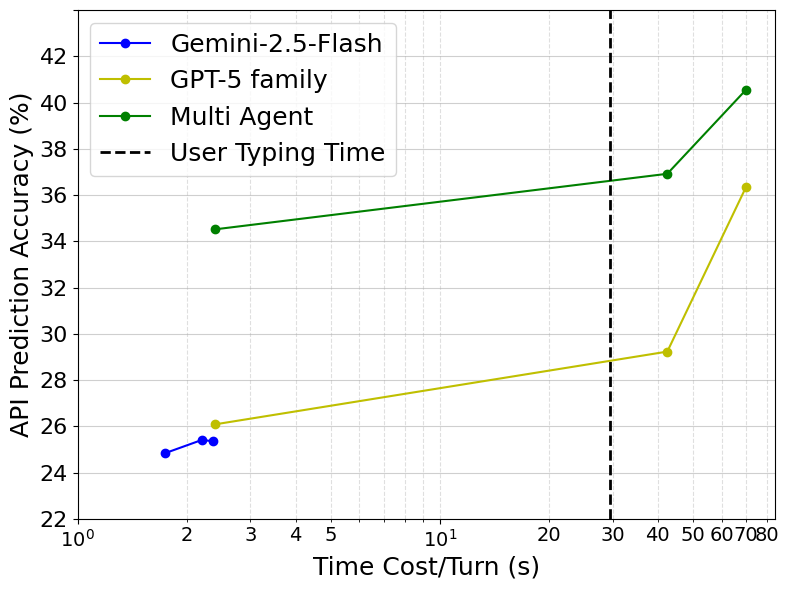

In [11]:
# Time figure
# Based on the throughput statistics on https://artificialanalysis.ai/leaderboards/providers
gpt5_low_ratio = 187.4
gpt5_low_latency = 0.92

gpt5_medium_ratio = 61.1
gpt5_medium_latency = 33.97

gpt5_high_ratio = 137.7
gpt5_high_latency = 61.51


gemini_ratio = 195.3
gemini_latency = 0.27


import matplotlib.pyplot as plt

# Data
txt_single = [
    "nano",
    "mini",
    "gpt-5"
]

txt_multi = [
    "nano + mini",
    "nano + gpt-5",
    "mini + gpt-5",
    "nano + mini + gpt-5"
]

time_gpt5_single = [
    gpt5_low_cost["complete_tokens_per_turn"] / gpt5_low_ratio + gpt5_low_latency, 
    gpt5_medium_cost["complete_tokens_per_turn"] / gpt5_medium_ratio + gpt5_medium_latency, 
    gpt5_high_cost["complete_tokens_per_turn"] / gpt5_high_ratio + gpt5_high_latency
]
api_correct_rate_gpt5_single = [
    gpt5_low_api_correct_rate["api_correct_rate"] * 100, 
    gpt5_medium_api_correct_rate["api_correct_rate"] * 100,
    gpt5_high_api_correct_rate["api_correct_rate"] * 100
]

time_gemini_single = [
    gemini_low_cost["complete_tokens_per_turn"] / gemini_ratio + gemini_latency,
    gemini_medium_cost["complete_tokens_per_turn"] / gemini_ratio + gemini_latency,
    gemini_high_cost["complete_tokens_per_turn"] / gemini_ratio + gemini_latency
]


api_correct_rate_gemini_single = [  
    gemini_low_api_correct_rate["api_correct_rate"] * 100,
    gemini_medium_api_correct_rate["api_correct_rate"] * 100,
    gemini_high_api_correct_rate["api_correct_rate"] * 100
]

time_multi = [
    max(time_gpt5_single[0], time_gemini_single[0]),
    max(time_gpt5_single[1], time_gemini_single[1]),
    max(time_gpt5_single[2], time_gemini_single[2])
]

api_correct_rate_multi = [
    multi_agent_results["low + low"] * 100,
    multi_agent_results["medium + medium"] * 100,
    multi_agent_results["high + high"] * 100,
]

# Plot: thinking_tokens vs api_correct_rate
from matplotlib.ticker import LogLocator, LogFormatter, NullFormatter, FixedLocator, FuncFormatter, MultipleLocator
fig, ax3 = plt.subplots(1, 1, figsize=(8, 6))
ax3.plot(time_gemini_single, api_correct_rate_gemini_single, marker='o', color='b', label='Gemini-2.5-Flash')
ax3.plot(time_gpt5_single, api_correct_rate_gpt5_single, marker='o', color='y', label='GPT-5 family')
ax3.plot(time_multi, api_correct_rate_multi, marker='o', color='g', label='Multi Agent')
# ax3.set_title('Prediction Accuracy vs Time Cost/Turn')
ax3.set_xlabel('Time Cost/Turn (s)', fontsize=18)
ax3.set_ylabel('API Prediction Accuracy (%)', fontsize=18)
ax3.set_xscale('log')
# more fine-grained x-axis on log scale
ax3.xaxis.set_major_locator(LogLocator(base=10, numticks=20))
ax3.xaxis.set_minor_locator(LogLocator(base=10, subs=(2,3,4,5,6,7,8,9), numticks=100))
# force labels for 5, 20, 30, 40 on log x-axis as minor ticks
_targets = [1.0,2.0, 3.0, 4.0,5.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0]
# keep major ticks as powers of 10
ax3.xaxis.set_major_locator(LogLocator(base=10, numticks=20))
# minor ticks at 2-9 per decade
ax3.xaxis.set_minor_locator(LogLocator(base=10, subs=(1,2,3,4,5,6,7,8,9), numticks=100))
# label only selected minor ticks
ax3.xaxis.set_minor_formatter(FuncFormatter(lambda v, p: (str(int(v)) if any(abs(v - t) / t < 1e-6 for t in _targets) else "")))
# ensure these values are in range
_xmin, _xmax = ax3.get_xlim()
ax3.set_xlim(min(_xmin, min(_targets)), max(_xmax, max(_targets)))
# enlarge x tick label fonts
ax3.tick_params(axis='x', which='major', labelsize=14)
ax3.tick_params(axis='x', which='minor', labelsize=14)
# denser grid on x
ax3.grid(which='both', axis='x', linestyle='--', alpha=0.4)
ax3.grid(which='major', axis='y', linestyle='-', alpha=0.6)

# set y axis range
ax3.set_ylim(20, 42)
# set y ticks every 2
ax3.yaxis.set_major_locator(MultipleLocator(2))
# ax3.set_xticklabels(fontsize=18)
ax3.set_yticklabels([20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42], fontsize=16)

# add legend
ax3.axvline(x=gpt5_low_cost["user_typing_time_per_turn"], color='black', linestyle='--', linewidth=2, label='User Typing Time')
ax3.legend(fontsize=18)

# add text for each point
# for i, txt in enumerate(txt_single):
#     ax3.annotate(txt, (complete_tokens_single[i], api_correct_rate_single[i]), textcoords="offset points", xytext=(0,10), ha='center')
# for i, txt in enumerate(txt_multi):
#     ax3.annotate(txt, (complete_tokens_multi[i], api_correct_rate_multi[i]), textcoords="offset points", xytext=(0,10), ha='center')

# add a dash line
plt.tight_layout()
plt.show()





/tmp/ipykernel_3863850/3990441127.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_yticklabels([20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42], fontsize=16)
/tmp/ipykernel_3863850/3990441127.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels([0.000, 0.002, 0.004, 0.006, 0.008, 0.010, 0.012, 0.014], fontsize=16)


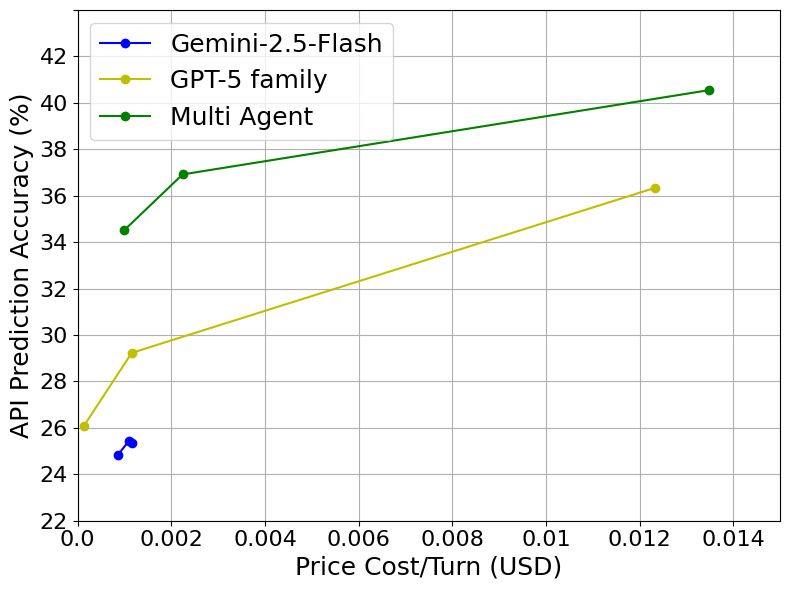

In [12]:
# price
import matplotlib.pyplot as plt

# Data
txt_single = [
    "nano",
    "mini",
    "gpt-5"
]

txt_multi = [
    "nano + mini",
    "nano + gpt-5",
    "mini + gpt-5",
    "nano + mini + gpt-5"
]

price_gpt5_single = [
    gpt5_low_cost["price_cost_per_turn"], 
    gpt5_medium_cost["price_cost_per_turn"], 
    gpt5_high_cost["price_cost_per_turn"]
]

api_correct_rate_gpt5_single = [
    gpt5_low_api_correct_rate["api_correct_rate"] * 100, 
    gpt5_medium_api_correct_rate["api_correct_rate"] * 100,
    gpt5_high_api_correct_rate["api_correct_rate"] * 100
]

price_gemini_single = [
    gemini_low_cost["price_cost_per_turn"],
    gemini_medium_cost["price_cost_per_turn"],
    gemini_high_cost["price_cost_per_turn"]
]

api_correct_rate_gemini_single = [
    gemini_low_api_correct_rate["api_correct_rate"] * 100,
    gemini_medium_api_correct_rate["api_correct_rate"] * 100,
    gemini_high_api_correct_rate["api_correct_rate"] * 100
]

price_multi = [
    price_gpt5_single[0] + price_gemini_single[0],
    price_gpt5_single[1] + price_gemini_single[1],
    price_gpt5_single[2] + price_gemini_single[2]
]

api_correct_rate_multi = [
    multi_agent_results["low + low"] * 100,
    multi_agent_results["medium + medium"] * 100,
    multi_agent_results["high + high"] * 100,
]

# Plot: thinking_tokens vs api_correct_rate
from matplotlib.ticker import LogLocator, LogFormatter, NullFormatter, FixedLocator, FuncFormatter, MultipleLocator
fig, ax3 = plt.subplots(1, 1, figsize=(8, 6))
ax3.plot(price_gemini_single, api_correct_rate_gemini_single, marker='o', color='b', label='Gemini-2.5-Flash')
ax3.plot(price_gpt5_single, api_correct_rate_gpt5_single, marker='o', color='y', label='GPT-5 family')
ax3.plot(price_multi, api_correct_rate_multi, marker='o', color='g', label='Multi Agent')
# ax3.set_title('Prediction Accuracy vs Time Cost/Turn')
ax3.set_xlabel('Price Cost/Turn (USD)', fontsize=18)
ax3.set_ylabel('API Prediction Accuracy (%)', fontsize=18)

ax3.grid(True)
# set y axis range
ax3.set_ylim(20, 42)
ax3.set_xlim(0.000, 0.015)
# set y ticks every 2
ax3.yaxis.set_major_locator(MultipleLocator(2))
# ax3.set_xticklabels(fontsize=18)
ax3.set_yticklabels([20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42], fontsize=16)
ax3.set_xticklabels([0.000, 0.002, 0.004, 0.006, 0.008, 0.010, 0.012, 0.014], fontsize=16)

# add legend
# ax3.axvline(x=gpt5_low_cost["user_typing_time_per_turn"], color='black', linestyle='--', label='User Typing Time')
ax3.legend(fontsize=18)

# add a dash line
plt.tight_layout()
plt.show()


/tmp/ipykernel_3863850/814350464.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([0, 10, 20, 30, 40, 50], fontsize=16)


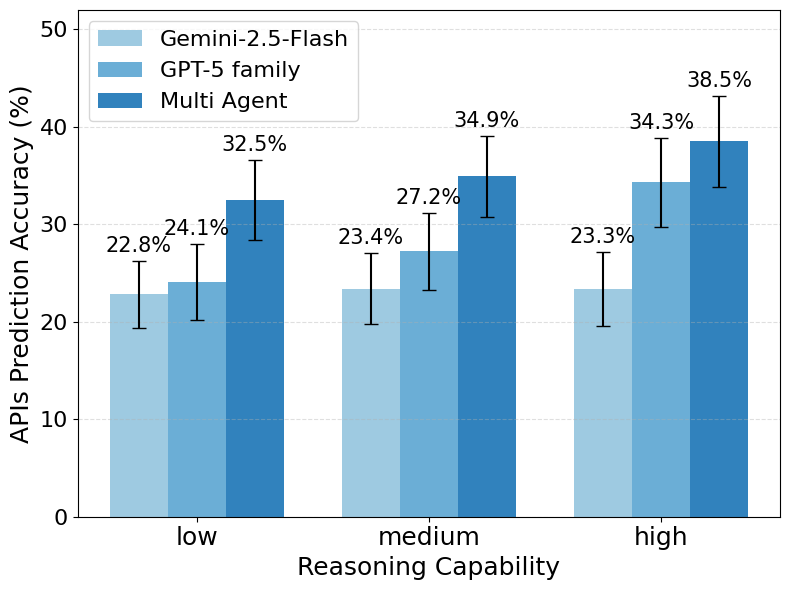

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Grouped categories
groups = ["low", "medium", "high"]

cmap = plt.get_cmap('tab20c')        # ListedColormap
colors = cmap.colors
c1, c2, c3 = colors[2], colors[1], colors[0]  

# Series values (percent)
gpt5_vals = [
    gpt5_low_api_correct_rate["api_correct_rate"] * 100,
    gpt5_medium_api_correct_rate["api_correct_rate"] * 100,
    gpt5_high_api_correct_rate["api_correct_rate"] * 100,
]

gemini_vals = [
    gemini_low_api_correct_rate["api_correct_rate"] * 100,
    gemini_medium_api_correct_rate["api_correct_rate"] * 100,
    gemini_high_api_correct_rate["api_correct_rate"] * 100,
]

multi_vals = [
    multi_agent_results["low + low"] * 100,
    multi_agent_results["medium + medium"] * 100,
    multi_agent_results["high + high"] * 100,
]

gpt5_ci = [
    get_confidence_interval(gpt5_low_api_correct_exp["api_correct_rate"]) * 100,
    get_confidence_interval(gpt5_medium_api_correct_exp["api_correct_rate"]) * 100,
    get_confidence_interval(gpt5_high_api_correct_exp["api_correct_rate"]) * 100,
]

gemini_ci = [
    get_confidence_interval(gemini_low_api_correct_exp["api_correct_rate"]) * 100,
    get_confidence_interval(gemini_medium_api_correct_exp["api_correct_rate"]) * 100,
    get_confidence_interval(gemini_high_api_correct_exp["api_correct_rate"]) * 100,
]

multi_ci = [
    get_confidence_interval(multi_agent_exp["low + low"]) * 100,
    get_confidence_interval(multi_agent_exp["medium + medium"]) * 100,
    get_confidence_interval(multi_agent_exp["high + high"]) * 100,
]

x = np.arange(len(groups))
width = 0.25

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

bars1 = ax.bar(x - width, gemini_vals, width, label='Gemini-2.5-Flash', yerr=gemini_ci, color=c1, capsize=5)
bars2 = ax.bar(x,         gpt5_vals , width, label='GPT-5 family', yerr=gpt5_ci, color=c2, capsize=5)
bars3 = ax.bar(x + width, multi_vals, width, label='Multi Agent', yerr=multi_ci, color=c3, capsize=5)


ax.set_xticks(x)
ax.set_xticklabels(groups, fontsize=18)
ax.set_ylabel('APIs Prediction Accuracy (%)', fontsize=18)
ax.set_xlabel("Reasoning Capability", fontsize=18)
ax.set_ylim(0, 52)
ax.set_yticklabels([0, 10, 20, 30, 40, 50], fontsize=16)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend(fontsize=16)

# annotate values on bars
def annotate_bars(bars, index):
    for i, bar in enumerate(bars):
        height_mean = bar.get_height()
        # change the height to the top of the ci
        if index == 0:
            height = height_mean + gemini_ci[i]
        elif index == 1:
            height = height_mean + gpt5_ci[i]
        else:
            height = height_mean + multi_ci[i]
        ax.text(bar.get_x() + bar.get_width()/2, height+0.5,
                f"{height_mean:.1f}%", ha='center', va='bottom', fontsize=15)

annotate_bars(bars1, index=0)
annotate_bars(bars2, index=1)
annotate_bars(bars3, index=2)

plt.tight_layout()
plt.show()
